In [1]:
import torch
import numpy as np

class DistributionConfidence:
	def __init__(self):
		pass

	def agent_decision(self, analysis):
		"""
		Make decisions based on confidence analysis
		"""
		if analysis['combined_score'] > 0.8:
			# Very confident - trust the match
			return "E", analysis['peak_index']

		elif analysis['combined_score'] > 0.5:
			# Moderately confident - useful but be cautious
			return "P1", analysis['peak_index']

		elif analysis['peak_to_wall_ratio'] > 5:
			# Strong single peak despite lower combined score
			return "P2", analysis['peak_index']

		else:
			# Not confident - don't rely on this match
			return "U", None

	def analyze(self, probs):
		"""
		Analyze a probability distribution and return multiple confidence metrics.

		Args:
			probs: torch.Tensor of probability values

		Returns:
			dict with various confidence scores
		"""
		probs = probs / probs.sum()  # Ensure valid distribution
		peak_val, peak_idx = torch.max(probs, dim=0)

		# Individual metrics
		peak_conf = peak_val.item()
		entropy = self._entropy(probs)
		ipr = self._ipr(probs)
		peak_to_wall = self._peak_to_wall(probs, peak_idx)
		kl_uniform = self._kl_from_uniform(probs)

		# Normalized metrics (0-1 scale)
		n_components = len(probs)
		max_entropy = np.log(n_components)  # For uniform distribution
		normalized_entropy = 1 - (entropy / max_entropy)  # Higher = more confident

		max_ipr = 1.0  # One peak at 1.0
		min_ipr = 1.0 / n_components  # Uniform distribution
		normalized_ipr = (ipr - min_ipr) / (max_ipr - min_ipr)

		# Combined confidence score (weighted average)
		combined_score = (
				peak_conf * 0.3 +
				normalized_entropy * 0.2 +
				normalized_ipr * 0.2 +
				min(peak_to_wall / 10, 1.0) * 0.2 +  # Cap at 1.0
				min(kl_uniform / 2, 1.0) * 0.1
		)

		return {
			'peak_confidence': peak_conf,
			'peak_index': peak_idx.item(),
			'entropy': entropy,
			'normalized_entropy': normalized_entropy,
			'ipr': ipr,
			'normalized_ipr': normalized_ipr,
			'peak_to_wall_ratio': peak_to_wall,
			'kl_from_uniform': kl_uniform,
			'combined_score': combined_score,
			'is_confident': combined_score > 0.7  # Adjust threshold as needed
		}

	def _entropy(self, probs):
		"""Calculate Shannon entropy"""
		probs = probs[probs > 0]
		return -torch.sum(probs * torch.log(probs)).item()

	def _ipr(self, probs):
		"""Calculate Inverse Participation Ratio"""
		return torch.sum(probs ** 2).item()

	def _peak_to_wall(self, probs, peak_idx):
		"""Calculate peak-to-wall ratio"""
		peak = probs[peak_idx]
		other_probs = torch.cat([probs[:peak_idx], probs[peak_idx + 1:]])
		mean_other = torch.mean(other_probs)
		return (peak / mean_other).item()

	def _kl_from_uniform(self, probs):
		"""Calculate KL divergence from uniform distribution"""
		n = len(probs)
		uniform = torch.ones(n) / n
		kl = torch.sum(probs * torch.log(probs / uniform))
		return kl.item()

	def path_continuity(self, fittings):
		"""
		Estimate how continuous is the path. E.g., [1,2,3,4] is continuous, [1,2,-1,4] is less so and [1,-1,1,4] is not continuous.
		"""
		fitting_p = -1
		fitting_pp = -1
		fitting_c = -1
		score_good = 0
		score_cnt = 0

		for i in range(len(fittings)):
			# If current index is 0, then we can't evaluate the fitting
			if i > 0:
				# If current fitting is previous + 1 or prev previous + 2, then that's good
				if (fittings[i] == fitting_p + 1) or (fittings[i] == fitting_pp + 2):
					score_good += 1
				score_cnt += 1

			fitting_pp = fitting_p
			fitting_p = fittings[i]

		return (score_good / score_cnt)

# Example usage
confidence = DistributionConfidence()

dist1 = torch.tensor([0.01, 0.01, 0.90, 0.04, 0.04])
dist2 = torch.tensor([0.2, 0.35, 0.36, 0.15, 0.12])

print("Distribution 1 Analysis:")
print(confidence.analyze(dist1))
print("decision: ", confidence.agent_decision(confidence.analyze(dist1)))
print("\nDistribution 2 Analysis:")
print(confidence.analyze(dist2))
print("decision: ", confidence.agent_decision(confidence.analyze(dist2)))

Distribution 1 Analysis:
{'peak_confidence': 0.8999999761581421, 'peak_index': 2, 'entropy': 0.4444379508495331, 'normalized_entropy': 0.7238551748930974, 'ipr': 0.8133999705314636, 'normalized_ipr': 0.7667499631643295, 'peak_to_wall_ratio': 36.0, 'kl_from_uniform': 1.1649999618530273, 'combined_score': 0.8263710185515794, 'is_confident': True}
decision:  ('E', 2)

Distribution 2 Analysis:
{'peak_confidence': 0.305084764957428, 'peak_index': 2, 'entropy': 1.5181580781936646, 'normalized_entropy': 0.0567153498343933, 'ipr': 0.23628267645835876, 'normalized_ipr': 0.04535334557294844, 'peak_to_wall_ratio': 1.7560975551605225, 'kl_from_uniform': 0.09127992391586304, 'combined_score': 0.15162511586770033, 'is_confident': False}
decision:  ('U', None)


In [2]:
import os, glob, re
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

#from .distribution_confidence import DistributionConfidence

class PathCompare:
	def __init__(self):
		self.device = "cuda:0"
		# We will use the base model from OpenAI, loaded via Hugging Face.
		model_name = "openai/clip-vit-base-patch32"
		# The CLIPProcessor handles both image preprocessing (resizing, normalizing)
		# and text tokenization.
		self.processor = CLIPProcessor.from_pretrained(model_name)
		# The CLIPModel contains:
		# 1. model.get_text_features()
		# 2. model.get_image_features()
		# although we realistically will only need image one
		self.model = CLIPModel.from_pretrained(model_name).to(self.device)
		print("CLIP Processor and Model loaded successfully.")
		self.confidence = DistributionConfidence()

	def extract_number(self, filename):
		# Extract the number from the filename (assuming it's the step count)
		# This regex looks for digits at the beginning, end, or between non-digits
		numbers = re.findall(r'\d+', filename)
		return int(numbers[-1]) if numbers else 0

	def load_images(self, path):
		imgs_path = glob.glob(path)
		imgs_path = sorted(imgs_path, key=self.extract_number)
		pil_images = [Image.open(fname).convert('RGB') for fname in imgs_path]
		return pil_images

	def load_path(self, base_dir):
		return self.load_images(base_dir + "/*.png")

	def get_embeddings(self, ref_path, cur_path):
		captions = [""]
		ref_path_inputs = self.processor(text=captions, images=ref_path, return_tensors="pt", padding=True)
		cur_path_inputs = self.processor(text=captions, images=cur_path, return_tensors="pt", padding=True)

		ref_path_inputs = {k: v.to(self.device) for k, v in ref_path_inputs.items()}  # Move to device
		cur_path_inputs = {k: v.to(self.device) for k, v in cur_path_inputs.items()}  # Move to device

		# get embeddings
		with torch.no_grad():
			ref_path_outputs = self.model(**ref_path_inputs)
			ref_path_embeds = ref_path_outputs.image_embeds
			cur_path_outputs = self.model(**cur_path_inputs)
			cur_path_embeds = cur_path_outputs.image_embeds
		return ref_path_embeds, cur_path_embeds
    
	def compare_paths(self, ref_path, cur_path):
		(ref_path_embeds, cur_path_embeds) = self.get_embeddings(ref_path, cur_path)
		# print(ref_path_embeds)

		ideal_path_normalized = F.normalize(ref_path_embeds, dim=1)
		current_path_normalized = F.normalize(cur_path_embeds, dim=1)

		# Get similarity to all reference frames in one matrix multiplication
		similarities = torch.mm(current_path_normalized, ideal_path_normalized.t()).squeeze()

		logit_scale = self.model.logit_scale.exp()
		logits = similarities * logit_scale
		# logits[range(len(logits)), range(len(logits[0]))] = 0 # we're not interested in each image compared to itself, so set the diagonal to 0
		# 4. Convert logits to probabilities using Softmax
		probs = F.softmax(logits, dim=-1)
		return probs

	def fit_single_img_to_ref_path(self, ref_path, img):
		probs = self.compare_paths(ref_path, [img])
		# print("Distribution 1 Analysis:")
		# print(confidence.analyze(dist1))
		# print("decision: ", confidence.agent_decision(confidence.analyze(dist1)))
		probs = probs.cpu().detach()
		dec = self.confidence.agent_decision(self.confidence.analyze(probs))
		return dec

	def fit_cur_path_to_ref_path(self, ref_path, cur_path):
		fittings = [self.fit_single_img_to_ref_path(ref_path, cp) for cp in cur_path]
		ft = [f[1] if f[0] != 'U' else -1 for f in fittings]
		cont = self.confidence.path_continuity(ft)
		return fittings, cont

	def visualize_probs(self, probs):
		# To accomodate probs having only 1 dimension because we only compare 1 image against a whole reference path, we need to check shape and unsqueeze if needed
		if len(probs.shape) == 1:
			probs = probs.unsqueeze(dim=0)
		rows = probs.shape[0]
		cols = probs.shape[1]
		probs = probs.cpu().detach().numpy()
		plt.figure(figsize=(56, 20))
		plt.subplot(1, 2, 2)
		plt.imshow(probs, cmap='viridis', vmin=0, vmax=1)
		plt.title("Path image similarities")
		plt.xlabel("Reference path")
		plt.ylabel("Current path")
		plt.xticks(range(cols), [f"{i + 1}" for i in range(cols)], rotation=45)
		plt.yticks(range(rows), [f"{i + 1}" for i in range(rows)])
		plt.colorbar()

		# Add text for probabilities
		for i in range(rows):
			for j in range(cols):
				plt.text(j, i, f"{probs[i, j]:.2f}", ha='center', va='center',
						 color='white' if probs[i, j] < 0.5 else 'black')

		plt.tight_layout()
		plt.show()


pc = PathCompare()


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP Processor and Model loaded successfully.


In [3]:
ref_imgs = pc.load_path("/ae_path_compare/1")
cur_imgs = pc.load_path("/ae_path_compare/tmp_cmp_s4")
alien_imgs = pc.load_path("/ae_path_compare/tmp_cmp_C")

In [4]:
(ref_path_embeds, cur_path_embeds) = pc.get_embeddings(ref_imgs, cur_imgs)

In [5]:
t1 = torch.zeros(3,2)
t1[0][0] = 1
t1[0][1] = 2
t1[1][0] = 3
t1[1][1] = 4
t1[2][0] = 5
t1[2][1] = 6
print(t1)
print(t1.shape)
print(t1.mean(dim=0))
print(t1.mean(dim=1))
print(t1.norm(dim=0))
print(t1.norm(dim=1))

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
torch.Size([3, 2])
tensor([3., 4.])
tensor([1.5000, 3.5000, 5.5000])
tensor([5.9161, 7.4833])
tensor([2.2361, 5.0000, 7.8102])


In [6]:
import torch.nn.functional as F
row0 = t1[0]
row1 = t1[1]
row2 = t1[2]
print(torch.norm(row0))
print(torch.sqrt(row0[0]**2 + row0[1]**2))
print(torch.norm(row1))
print(torch.sqrt(row1[0]**2 + row1[1]**2))
print(torch.dot(row0, row1))
print(row0[0] * row1[0] + row0[1] * row1[1])
cosine_similarity = torch.dot(row0, row1) / (torch.sqrt(row0[0]**2 + row0[1]**2) * torch.sqrt(row1[0]**2 + row1[1]**2))
print(cosine_similarity)
print(F.cosine_similarity(row0, row1, dim=0))
print(F.cosine_similarity(row1, row2, dim=0))

tensor(2.2361)
tensor(2.2361)
tensor(5.)
tensor(5.)
tensor(11.)
tensor(11.)
tensor(0.9839)
tensor(0.9839)
tensor(0.9987)


In [7]:
row0_n = F.normalize(row0, dim=0)
row1_n = F.normalize(row1, dim=0)
print(row0_n)
print(row0_n.norm(dim=0))
print(row0.norm(dim=0))
print(F.cosine_similarity(row0_n, row1_n, dim=0))

logit_scale = pc.model.logit_scale.exp()
print(logit_scale)

cs = F.cosine_similarity(row0_n, row1_n, dim=0) * logit_scale
print(cs)

tensor([0.4472, 0.8944])
tensor(1.0000)
tensor(2.2361)
tensor(0.9839)
tensor(100., device='cuda:0', grad_fn=<ExpBackward0>)
tensor(98.3870, device='cuda:0', grad_fn=<MulBackward0>)


In [8]:
print(t1)
print(t1.norm(dim=0))
print(t1.mean(dim=0))
print(t1.mode(dim=1))
print(t1.median(dim=0))

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([5.9161, 7.4833])
tensor([3., 4.])
torch.return_types.mode(
values=tensor([1., 3., 5.]),
indices=tensor([0, 0, 0]))
torch.return_types.median(
values=tensor([3., 4.]),
indices=tensor([1, 1]))


In [9]:
print(ref_path_embeds.shape)

torch.Size([10, 512])


In [10]:
import torch.nn.functional as F

print(ref_path_embeds.shape)
print(cur_path_embeds.shape)
#print(ref_path_embeds)
#print(cur_path_embeds)

#print(ref_path_embeds.mean(dim=0))
#print(cur_path_embeds.mean(dim=0))
ref_mean = ref_path_embeds.mean(dim=0)
cur_mean = cur_path_embeds.mean(dim=0)
print("Ref path 1 vs sidestep 4: ", F.cosine_similarity(ref_mean, cur_mean, dim=0))

alien_imgs = pc.load_path("/ae_path_compare/tmp_cmp_D")

(ref_path_embeds, alien_path_embeds) = pc.get_embeddings(ref_imgs, alien_imgs)
alien_mean = alien_path_embeds.mean(dim=0)
print("Ref path 1 vs alien: ", F.cosine_similarity(ref_mean, alien_mean, dim=0))
print("Reg path 1 vs itself: ", F.cosine_similarity(ref_mean, ref_mean, dim=0))

torch.Size([10, 512])
torch.Size([5, 512])
Ref path 1 vs sidestep 4:  tensor(0.9860, device='cuda:0')
Ref path 1 vs alien:  tensor(0.9537, device='cuda:0')
Reg path 1 vs itself:  tensor(1., device='cuda:0')


torch.Size([5, 10])


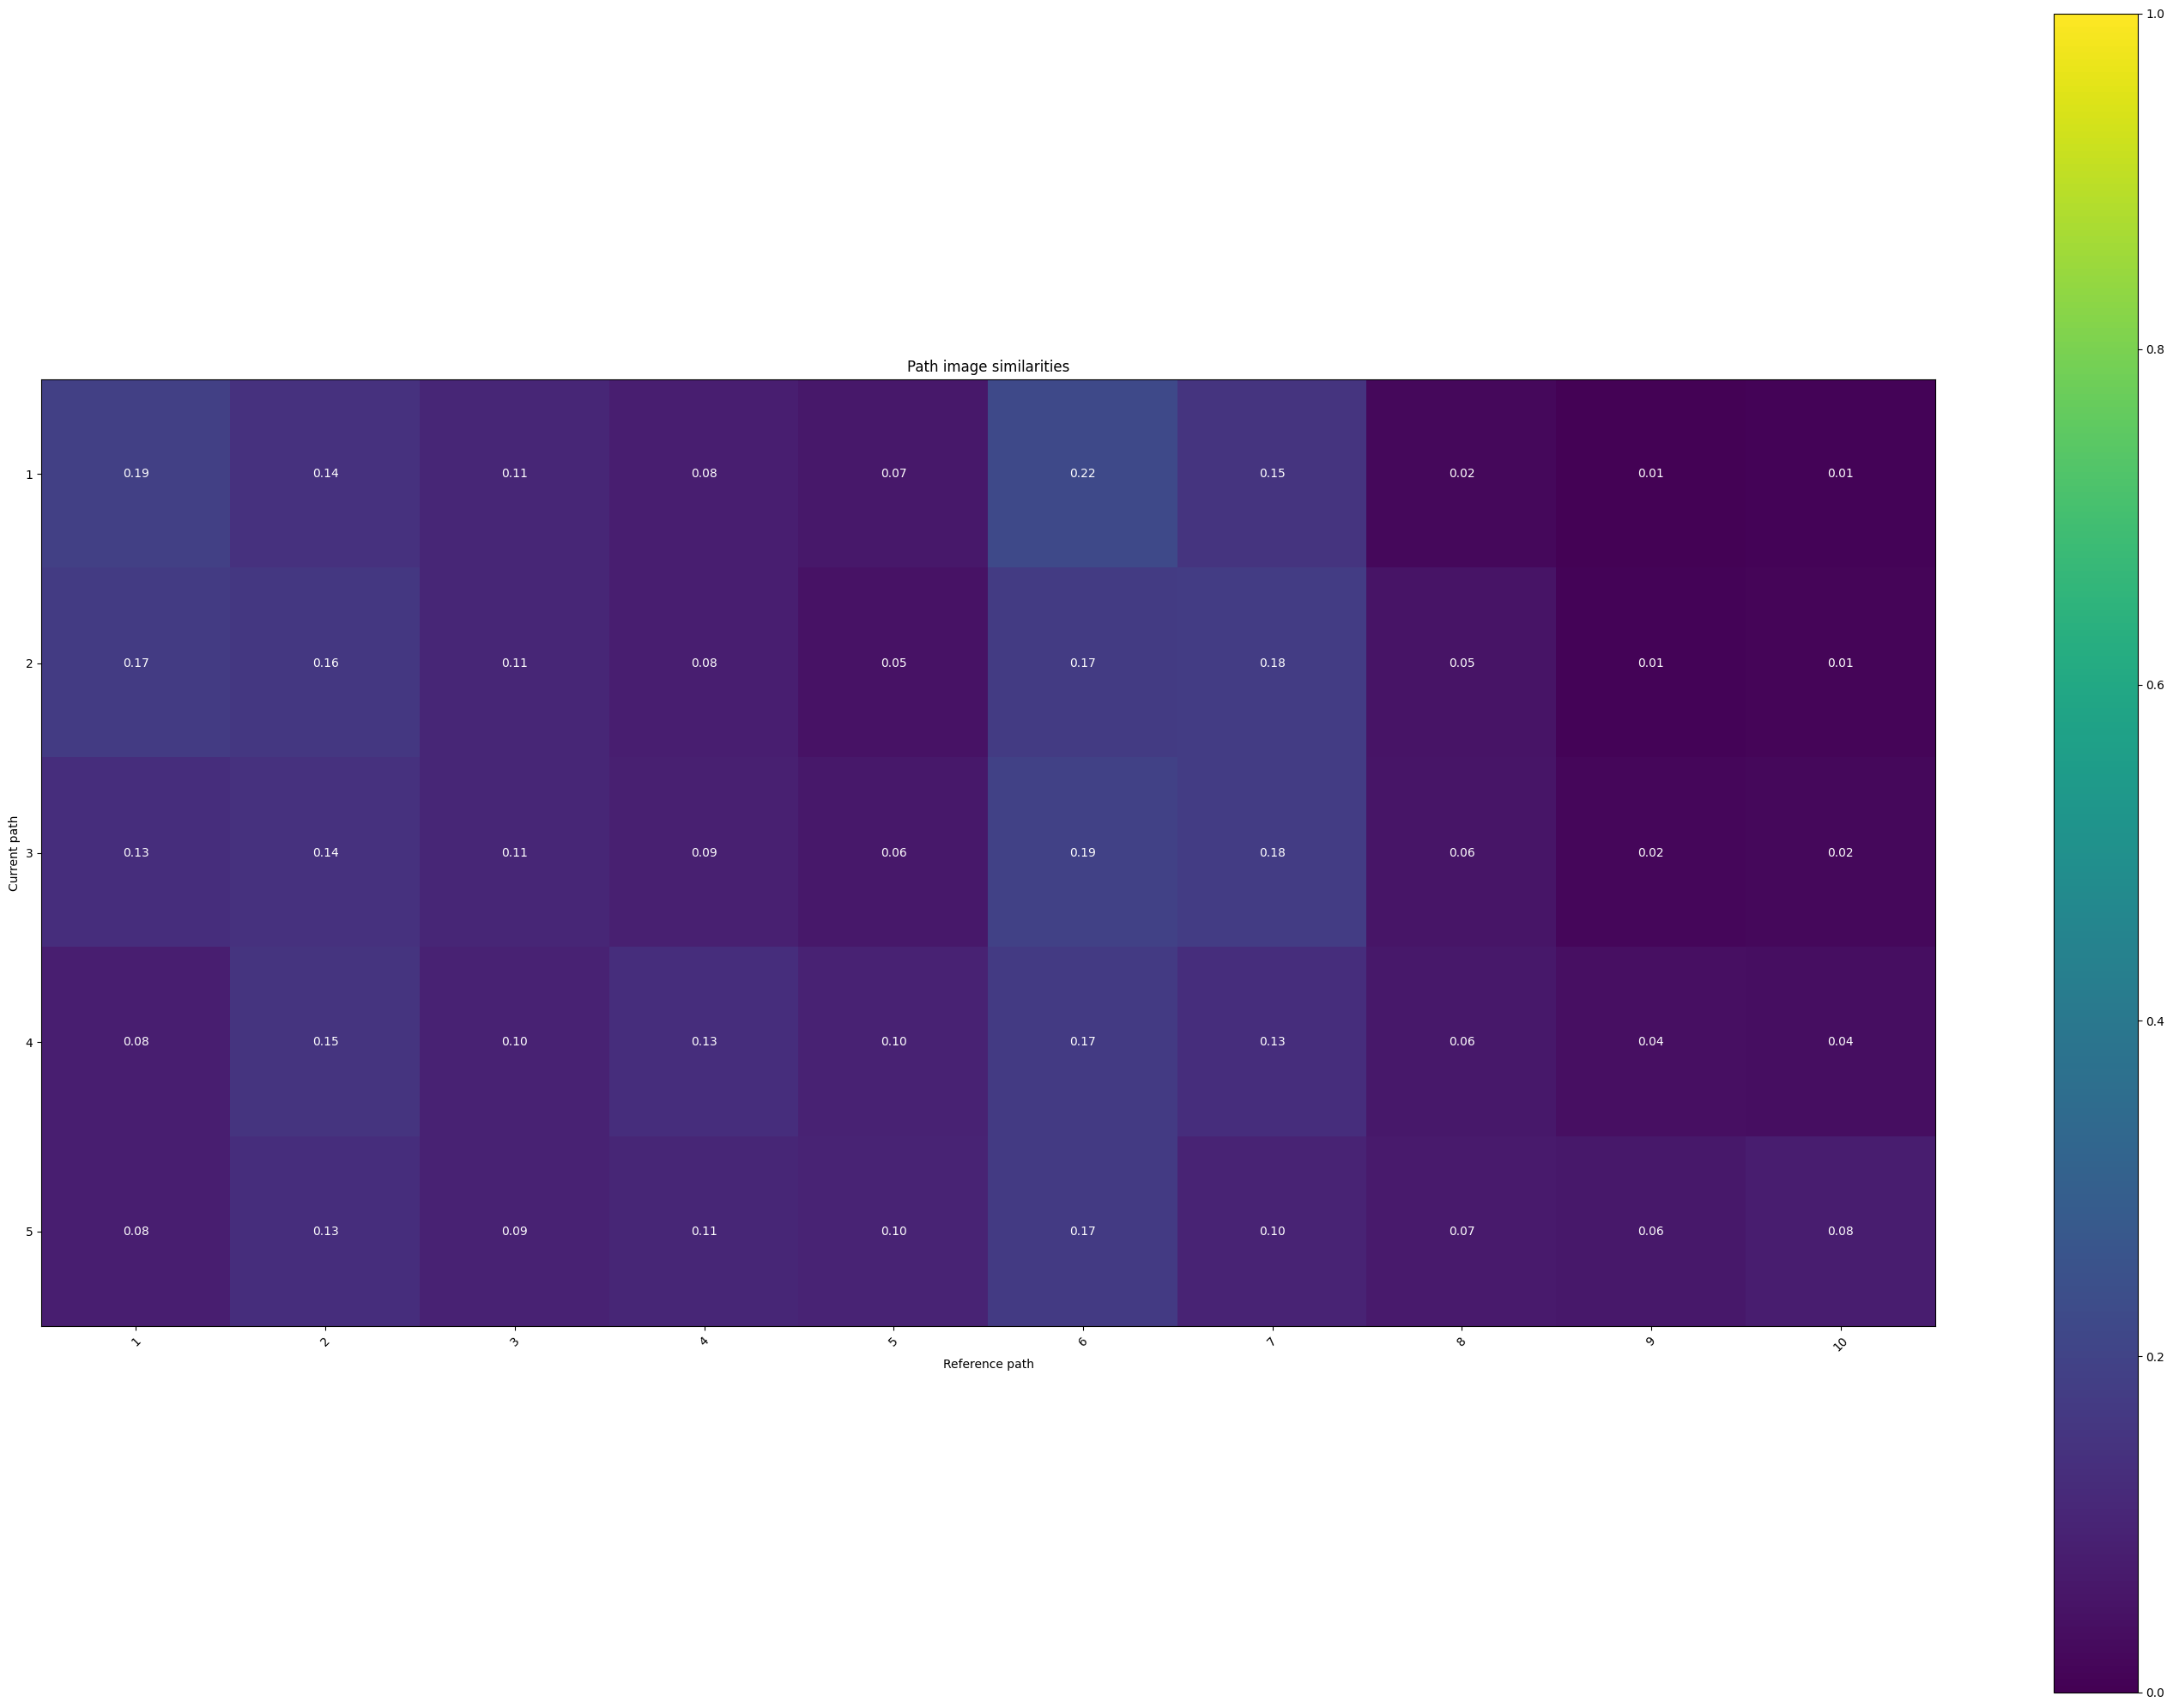

In [11]:
probs = pc.compare_paths(ref_imgs, cur_imgs)
print(probs.shape)
pc.visualize_probs(probs)

In [2]:
import torch, glob, re
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np

class DINOv2Encoder:
    def __init__(self, device="cuda:0"):
        self.device = device
        # Load DINOv2 model (base version, 768-dim embeddings)
# 94 vs 58 = 36; 95-45=50
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
#        self.model = AutoModel.from_pretrained('facebook/dinov2-base').to(device)

# 91 vs 47 = 44; 89 - 40=49
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vitl16-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vitl16-pretrain-lvd1689m').to(device)

# 92 vs 59 = 33; 91 - 40=51
        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vits16-pretrain-lvd1689m')
        self.model = AutoModel.from_pretrained('facebook/dinov3-vits16-pretrain-lvd1689m').to(device)

# 94 vs 64 = 30; 94 - 54=40
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vits16plus-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vits16plus-pretrain-lvd1689m').to(device)
        
# 95 vs 58 = 37; 93 - 53=40
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m').to(device)
        
# 88 vs 30 = 58; 88 vs 24=64
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vith16plus-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vith16plus-pretrain-lvd1689m').to(device)       

# 93 vs 43 = 50; 94 - 40=54
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-convnext-large-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-convnext-large-pretrain-lvd1689m').to(device)       

# 93 vs 62 = 31; 97 - 68=29
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-convnext-tiny-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-convnext-tiny-pretrain-lvd1689m').to(device)       

# 96 vs 68 = 28; 96 - 65=31
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-convnext-small-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-convnext-small-pretrain-lvd1689m').to(device)       

# 93 vs 56 = 37; 96 - 54=42
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-convnext-base-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-convnext-base-pretrain-lvd1689m').to(device)       

# 88 vs 34; 85-27=58
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vit7b16-pretrain-lvd1689m')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vit7b16-pretrain-lvd1689m').to(device)       

#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vitl16-chmv2-dpt-head')
#        self.model = AutoModel.from_pretrained('facebook/dinov3-vitl16-chmv2-dpt-head').to(device)       

# 99 vs 87; 99-88=11
#        self.processor = AutoImageProcessor.from_pretrained('facebook/dinov3-vit7b16-pretrain-sat493m')
#       self.model = AutoModel.from_pretrained('facebook/dinov3-vit7b16-pretrain-sat493m').to(device)       

# 88 vs 34; 85 - 27=58
#        self.processor = AutoImageProcessor.from_pretrained('mirekphd/dinov3-vit7b16-pretrain-lvd1689m-fp16')
#        self.model = AutoModel.from_pretrained('mirekphd/dinov3-vit7b16-pretrain-lvd1689m-fp16').to(device)       

        self.processor.size = {'height': 448, 'width': 448} # 88 vs 24 with vith16plus

# mirekphd/dinov3-vit7b16-pretrain-lvd1689m-fp16
    def encode_image(self, image):
        """
        Encode a single image into a feature vector.
        
        Args:
            image: PIL Image or numpy array (BGR from AI2-THOR)
        
        Returns:
            torch.Tensor of shape (768,) - feature embedding
        """
        # Convert BGR to RGB if needed
        if isinstance(image, np.ndarray):
            if image.shape[-1] == 3:
                image = Image.fromarray(image[:, :, ::-1])  # BGR to RGB
        elif not isinstance(image, Image.Image):
            image = Image.fromarray(image)
        
        # Process and encode
        inputs = self.processor(images=image, return_tensors='pt')
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            # DINOv2 outputs: last_hidden_state shape (1, 197, 768)
            # We take the [CLS] token (first token) as the image representation
            embedding = outputs.last_hidden_state[:, 0, :].squeeze()  # Shape: (768,)
        
        return embedding
    
    def encode_batch(self, images):
        """
        Encode a batch of images.
        
        Args:
            images: List of PIL Images or numpy arrays
        
        Returns:
            torch.Tensor of shape (N, 768)
        """
        embeddings = [self.encode_image(img) for img in images]
        return torch.stack(embeddings)

    def extract_number(self, filename):
        # Extract the number from the filename (assuming it's the step count)
        # This regex looks for digits at the beginning, end, or between non-digits
        numbers = re.findall(r'\d+', filename)
        return int(numbers[-1]) if numbers else 0

    def load_images(self, path):
        imgs_path = glob.glob(path)
        imgs_path = sorted(imgs_path, key=self.extract_number)
        pil_images = [Image.open(fname).convert('RGB') for fname in imgs_path]
        return pil_images

    def load_path(self, base_dir):
        return self.load_images(base_dir + "/*.png")

In [3]:
de = DINOv2Encoder()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [4]:
ref_path1 = de.load_path("/ae_path_compare/1")
path1_s4 = de.load_path("/ae_path_compare/tmp_cmp_s4")
alien_path = de.load_path("/ae_path_compare/tmp_cmp_C")

In [5]:
im1 = de.encode_image(alien_path[0])

In [6]:
im1.shape

torch.Size([384])

In [7]:
im1

tensor([-1.8011e-01, -3.8723e-01, -1.1193e-01, -2.9500e-01,  2.7902e-02,
         2.3077e-01, -9.4426e-02,  4.4027e-01, -4.1833e-01, -1.8934e-01,
         1.5758e-01, -4.9909e-01,  1.0024e+00, -9.5006e-02, -5.2005e-02,
        -8.9199e-01, -4.8267e-01, -6.3794e-01,  1.8801e-01, -5.8428e-01,
        -6.5135e-01,  4.3943e-02,  6.8815e-01,  9.5847e-04, -1.2161e+00,
         1.2179e+00,  9.5789e-01,  6.8032e-01, -4.8217e-01,  2.1493e-01,
        -1.0695e-01,  4.1926e-01,  3.1644e-01, -4.7922e-01,  2.2738e-01,
         2.9519e-01,  3.2927e-01,  8.0110e-01,  4.0620e-01, -1.7838e-01,
         4.3467e-03,  9.8504e-01, -1.5131e-01, -8.7355e-02,  3.6550e-01,
         1.4247e-01, -3.4544e-01,  1.8217e-01, -1.3127e-01,  9.2312e-01,
         7.7140e-01, -6.6584e-01,  6.1872e-01, -1.0189e-01,  3.0599e-01,
         3.7690e-01, -6.2808e-01, -2.2667e-01, -2.5386e-01,  1.4801e-01,
         5.1765e-01,  1.5025e-01,  2.7793e-01,  3.4049e-01,  2.6147e-01,
        -5.5057e-01,  9.0925e-01, -3.0419e-01, -2.9

In [8]:
ref_path1_em = de.encode_batch(ref_path1)
path1_s4_em = de.encode_batch(path1_s4)
alien_path_em = de.encode_batch(alien_path)

In [9]:
import torch.nn.functional as F

path1_s4 = de.load_path("/ae_path_compare/tmp_cmp_s4")
alien_path = de.load_path("/ae_path_compare/tmp_cmp_D")
ref_path1 = de.load_path("/ae_path_compare/1")


ref_path1_em = de.encode_batch(ref_path1)
path1_s4_em = de.encode_batch(path1_s4)
alien_path_em = de.encode_batch(alien_path)

print(ref_path1_em.shape)
print(path1_s4_em.shape)
#print(ref_path_embeds)
#print(cur_path_embeds)

#print(ref_path_embeds.mean(dim=0))
#print(cur_path_embeds.mean(dim=0))
ref_mean = ref_path1_em.mean(dim=0)
cur_mean = path1_s4_em.mean(dim=0)
print("Ref path 1 vs sidestep 4: ", F.cosine_similarity(ref_mean, cur_mean, dim=0))

alien_mean = alien_path_em.mean(dim=0)
print("Ref path 1 vs alien: ", F.cosine_similarity(ref_mean, alien_mean, dim=0))
print("Reg path 1 vs itself: ", F.cosine_similarity(ref_mean, ref_mean, dim=0))

torch.Size([10, 384])
torch.Size([5, 384])
Ref path 1 vs sidestep 4:  tensor(0.9119, device='cuda:0')
Ref path 1 vs alien:  tensor(0.4081, device='cuda:0')
Reg path 1 vs itself:  tensor(1., device='cuda:0')


In [178]:
import torch
t_arr = torch.zeros((1, 2, 3))
t_arr[0][0][0] = 1
t_arr[0][0][1] = 2
t_arr[0][0][2] = 3
t_arr[0][1][0] = 4
t_arr[0][1][1] = 5
t_arr[0][1][2] = 6

In [183]:
print(t_arr)
print(t_arr[:, 0, :])
print(t_arr[:, 1, :])
print(t_arr[:, 0, :].squeeze())

tensor([[[1., 2., 3.],
         [4., 5., 6.]]])
tensor([[1., 2., 3.]])
tensor([[4., 5., 6.]])
tensor([1., 2., 3.])
